# A complete, inspectable TME workflow

**完整的 TME 分析工作流**

Follow counts → TPM → method-specific expression inputs. Each stage is an explicit iobrx call with its own wall-clock timer; loading and plotting are outside the analysis timer.

This notebook uses public [IOBR release fixtures](https://github.com/IOBR/IOBR/releases/tag/data-v1.0). Source URLs and checksums are in [data/manifest.json](data/manifest.json). Figures are descriptive; no clinical outcome labels are supplied.

**Setup:** from the repository root, install with `python -m pip install ".[tutorials]"`. Restart the notebook kernel after installation.

In [1]:
%matplotlib inline
from pathlib import Path
from time import perf_counter
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import iobrx

# Works from the repository root or from the tutorials directory.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tutorials" / "_common.py").exists())
sys.path.insert(0, str(ROOT / "tutorials"))
from _common import (configure, load, tpm_input, runtime_info, numeric_scores,
                     short_samples, clean_labels, panel, heatmap, scatter,
                     stacked, composition_figure, fractions, save_figure, save_result, COLORS, TEAL, RUST, NAVY)
configure(2)
iobrx.set_threads(8)
display(runtime_info())


{'iobrx': '0.2.0',
 'threads': 8,
 'native_available': True,
 'native_reason': None,
 'sorting': 'numpy CPU dispatch',
 'requires_avx512': False,
 'bundled_openblas_found': True,
 'versions': {'numpy': '2.2.6',
  'pandas': '2.3.3',
  'scipy': '1.16.3',
  'scikit-learn': '1.7.2',
  'iobrpy': '0.2.1',
  'gseapy': '1.3.1',
  'matplotlib': '3.10.9'}}

## 1. Inspect the input / 检查输入

Expression matrices are **genes × samples**. The analysis uses every sample; any figure subset is stated explicitly.

In [2]:
counts = load("eset_stad")
annotation = load("anno_grch38")
input_shape = counts.shape
display(counts.iloc[:5, :4])


,TCGA-BR-6455,TCGA-BR-7196,TCGA-BR-8371,TCGA-BR-8380
rownames,,,,
ENSG00000000003,8006.0,2114.0,767.0,1556.0
ENSG00000000005,1.0,0.0,5.0,5.0
ENSG00000000419,3831.0,2600.0,1729.0,1760.0
ENSG00000000457,1126.0,745.0,1040.0,1260.0
ENSG00000000460,857.0,463.0,231.0,432.0


## 2. Run the analysis / 运行分析

The timer covers the call below, including its resource setup. Data loading above and plotting below are excluded. This is a single run; repeated benchmark medians are reported separately in the README.

In [3]:
started = perf_counter()
result, stage_seconds = {}, {}
def run_stage(name, function):
    start = perf_counter()
    output = function()
    stage_seconds[name] = perf_counter() - start
    result[name] = output
    return output

symbols = run_stage("annotation", lambda: iobrx.anno_eset(counts, annotation, method="mean"))
tpm = run_stage("TPM", lambda: iobrx.count2tpm(counts, check_data=True, remove_version=True))
log_expression = np.log2(tpm + 1)
scores = run_stage("signatures", lambda: iobrx.calculate_sig_score(log_expression, "signature_collection", "integration", n_threads=8))
cib = run_stage("CIBERSORT", lambda: iobrx.cibersort(tpm, perm=100, QN=False, n_threads=8))
epi = run_stage("EPIC", lambda: iobrx.epic(tpm))
qnt = run_stage("quanTIseq", lambda: iobrx.quantiseq(tpm, tumor=True, rmgenes="default"))
mcp = run_stage("MCP-counter", lambda: iobrx.mcpcounter(log_expression))
est = run_stage("ESTIMATE", lambda: iobrx.estimate_score(log_expression, platform="rnaseq"))
elapsed = perf_counter() - started
display(save_result(result, "12_complete_workflow", elapsed, input_shape))

Annotation DataFrame shape: (66533, 11)
Row number of original eset: 60483
Probes matched annotation: 60322 / 60483
99.73% of probes were annotated
Row number after filtering: 50181


Running quanTIseq deconvolution module
Gene expression normalization and re-annotation (arrays: False)
Removing 17 noisy genes
Removing 15 genes with high expression in tumors
Signature genes found in data set: 137/138 (99.28%)
Mixture deconvolution (method: lsei)


Deconvoluting samples:   0%|          | 0/10 [00:00<?, ?it/s]

Deconvoluting samples: 100%|██████████| 10/10 [00:00<00:00, 15103.72it/s]

Deconvoluting samples:   0%|          | 0/10 [00:00<?, ?it/s]

Deconvoluting samples: 100%|██████████| 10/10 [00:00<00:00, 11516.49it/s]

Deconvolution successful!
Population 'T cells': 15 marker genes matched.
Population 'CD8 T cells': 1 marker genes matched.
Population 'Cytotoxic lymphocytes': 7 marker genes matched.
Population 'B lineage': 9 marker genes matched.
Population 'NK cells': 8 marker genes matched.
Population 'Monocytic lineage': 7 marker genes matched.
Population 'Myeloid dendritic cells': 6 marker genes matched.
Population 'Neutrophils': 15 marker genes matched.
Population 'Endothelial cells': 31 marker genes matched.
Population 'Fibroblasts': 8 marker genes matched.
 Starting estimate_score
Merged dataset includes 10141 genes.
 Gene set 'StromalSignature' overlap: 138 genes
 Gene set 'ImmuneSignature' overlap: 140 genes
Completed in 28.663 s; input 60,483 features × 10 samples.


,analysis,seconds,input_shape,output_shapes,threads
0,12_complete_workflow,28.663301,"[60483, 10]","{'annotation': [50181, 10], 'TPM': [48058, 10]...",8


In [4]:
display(result.head() if isinstance(result, pd.DataFrame) else {key: value.shape if isinstance(value, pd.DataFrame) else list(value) for key, value in result.items()})

{'annotation': (50181, 10),
 'TPM': (48058, 10),
 'signatures': (10, 940),
 'CIBERSORT': (10, 25),
 'EPIC': ['mRNAProportions', 'cellFractions', 'fit_gof'],
 'quanTIseq': (10, 12),
 'MCP-counter': (10, 10),
 'ESTIMATE': (3, 10)}

## 3. Visualize and export / 作图与导出

White background, restrained colors, thin axes and editable vector text. Display transformations do not overwrite the analysis result. `S01`, `S02`, … follow the input sample order, as recorded in the mapping table below.

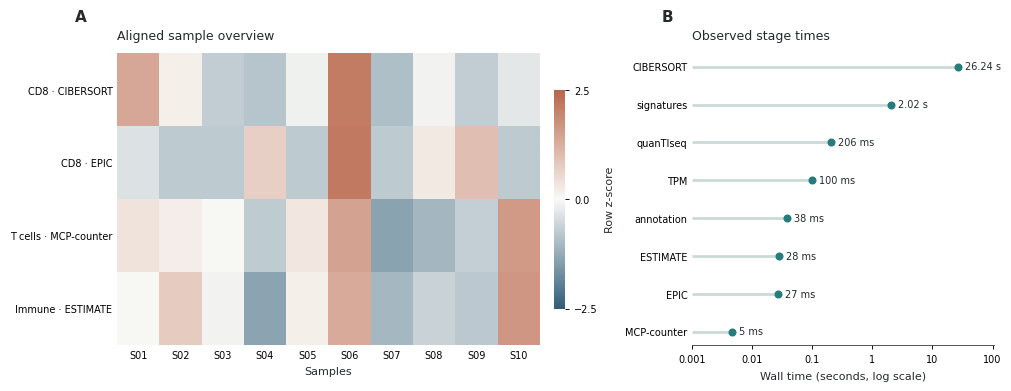

,seconds
annotation,0.037621
TPM,0.099747
signatures,2.021364
CIBERSORT,26.236669
EPIC,0.027031
quanTIseq,0.205545
MCP-counter,0.004587
ESTIMATE,0.027865


In [5]:
cell_columns = [c for c in cib if c not in ["P-value", "Correlation", "RMSE"]]
cd8 = next(c for c in cell_columns if "CD8" in c)
epic_cd8 = next(c for c in epi["cellFractions"] if "CD8" in c)
immune = next(name for name in est.index if "immune" in str(name).lower())
summary = pd.DataFrame({"CD8 · CIBERSORT": cib[cd8], "CD8 · EPIC": epi["cellFractions"][epic_cd8],
                        "T cells · MCP-counter": mcp.loc["T cells"], "Immune · ESTIMATE": est.loc[immune]})
fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.8), gridspec_kw={"width_ratios": [1.4, 1]}, layout="constrained")
heatmap(axes[0], summary.T, max_rows=4, max_samples=10)
timing = pd.Series(stage_seconds).sort_values()
axes[1].hlines(np.arange(len(timing)), 0.001, timing, color="#CBD9D7", linewidth=2)
axes[1].scatter(timing, np.arange(len(timing)), s=23, c=TEAL, zorder=3)
axes[1].set_yticks(np.arange(len(timing)), timing.index)
axes[1].set(xlabel="Wall time (seconds, log scale)", xscale="log", xlim=(0.001, timing.max() * 4))
axes[1].set_xticks([0.001, 0.01, 0.1, 1, 10, 100], ["0.001", "0.01", "0.1", "1", "10", "100"])
axes[1].minorticks_off()
axes[1].spines["left"].set_visible(False)
axes[1].tick_params(axis="y", length=0)
for y, value in enumerate(timing):
    label = f"{value * 1000:.0f} ms" if value < 1 else f"{value:.2f} s"
    axes[1].annotate(label, (value, y), xytext=(5, 0), textcoords="offset points", va="center", fontsize=7)
panel(axes[0], "A", "Aligned sample overview")
panel(axes[1], "B", "Observed stage times")
save_figure(fig, '12_complete_workflow')
display(pd.Series(stage_seconds, name="seconds").to_frame())


In [6]:
sample_ids = expression.columns if "expression" in globals() else counts.columns if "counts" in globals() else tpm.columns
display(pd.DataFrame({"plot_label": short_samples(sample_ids), "original_sample_id": sample_ids}).head(30))

,plot_label,original_sample_id
0,S01,TCGA-BR-6455
1,S02,TCGA-BR-7196
2,S03,TCGA-BR-8371
3,S04,TCGA-BR-8380
4,S05,TCGA-BR-8592
5,S06,TCGA-BR-8686
6,S07,TCGA-BR-A4IV
7,S08,TCGA-BR-A4J4
8,S09,TCGA-BR-A4J9
9,S10,TCGA-FP-7916


## 4. Interpretation and limits / 解读与边界

Annotation is shown as a separate workflow branch; count2tpm already performs its own identifier mapping. Do not feed log expression to methods expecting linear TPM. The overview scales features only for display, because deconvolution fractions and marker/enrichment scores have different units. No response, survival, or clinical groups are inferred from these unlabeled fixtures.

**Reusing this tutorial:** replace the input-loading cell with your own `pd.read_csv(..., index_col=0)`; keep the matrix orientation, identifier type and expression scale consistent with this example. Check gene overlap before interpreting estimates.

Figures are written to `tutorials/figures/12_complete_workflow.png`, `.pdf`, and `.svg`. Compact output tables and timing metadata are written to `tutorials/results/`. Large count/TPM matrices remain in `result`; save them explicitly with `result.to_parquet(...)` if needed.